In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
df = pd.read_csv("European_Bank (3).csv")

df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df = df.drop(["CustomerId","Surname","Year"], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df = pd.get_dummies(df, columns=["Geography","Gender"], drop_first=True)

In [ ]:
df["BalanceSalaryRatio"] = df["Balance"] / df["EstimatedSalary"]

df["AgeTenure"] = df["Age"] * df["Tenure"]

df["ProductDensity"] = df["NumOfProducts"] / (df["Tenure"] + 1)

In [ ]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8085
Precision: 0.5952380952380952
Recall: 0.18427518427518427
F1 Score: 0.28142589118198874
ROC AUC: 0.7742226047310794


In [ ]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

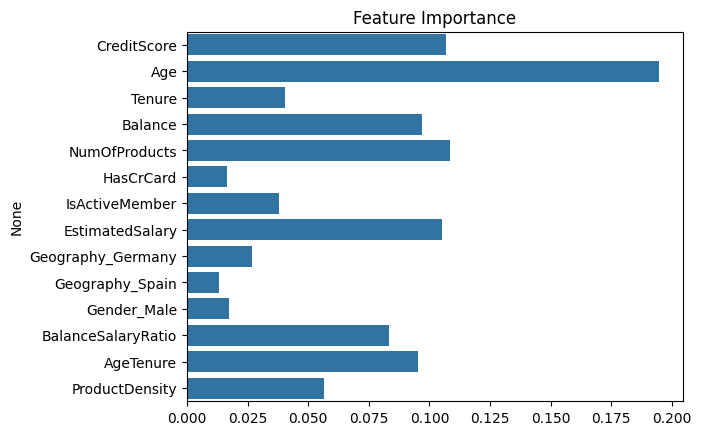

In [ ]:
importance = rf.feature_importances_

sns.barplot(x=importance, y=X.columns)

plt.title("Feature Importance")

plt.show()

In [ ]:
risk_scores = rf.predict_proba(X_test)[:,1]

risk_scores[:10]

array([0.01 , 0.14 , 0.035, 0.005, 0.135, 0.23 , 0.015, 0.27 , 0.51 ,
       0.085])

In [ ]:
def risk_level(p):
    if p > 0.6:
        return "High Risk"
    elif p > 0.3:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_category = [risk_level(p) for p in risk_scores]

risk_category[:10]

['Low Risk',
 'Low Risk',
 'Low Risk',
 'Low Risk',
 'Low Risk',
 'Low Risk',
 'Low Risk',
 'Low Risk',
 'Medium Risk',
 'Low Risk']

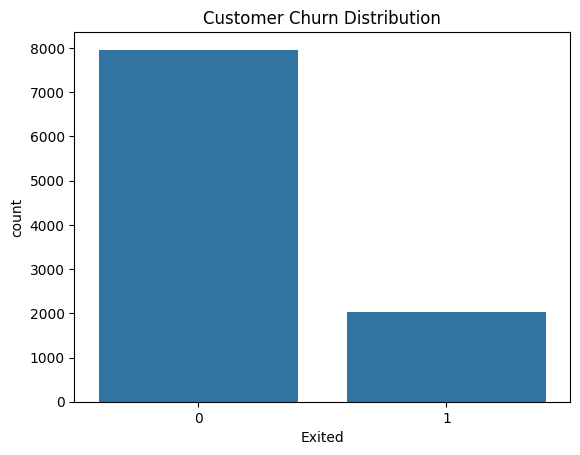

In [ ]:
sns.countplot(x='Exited', data=df)

plt.title("Customer Churn Distribution")

plt.show()